In [9]:
import numpy as np
import pandas as pd
def prediction(x, w, b):
    v = np.dot(x, w) + b
    return 1 if v > 0 else 0

def perceptron_step(X, Y, W, b, learn_rate = 0.01):
    for x,y in zip(X,Y):
        y_hat = prediction(x,W,b)
        if(y-y_hat==1):
            W=W+learn_rate*x.reshape(2,1)
            b=b+learn_rate
        elif ( y-y_hat==-1):
            W=W-learn_rate*x.reshape(2,1)
            b=b-learn_rate
    return W, b

In [10]:
def train_perceptron_algorithm(X, y, learn_rate=0.01, num_epochs=25):
    x_min, x_max = min(X.T[0]), max(X.T[0])
    y_min, y_max = min(X.T[1]), max(X.T[1])
    W = np.array(np.random.rand(2,1))
    b = np.random.rand(1)[0] + x_max
    boundary_lines = []
    for i in range(num_epochs):
        W, b = perceptron_step(X, y, W, b, learn_rate)
        boundary_lines.append((-W[0]/W[1], -b/W[1]))
    return boundary_lines


In [11]:
import matplotlib.pyplot as plt
def plot_line(m, b, linestyle='dashed', color='gray', fill=False):
    x = np.arange(-10.0, 10.0, 0.1)
    plt.plot(x, m*x+b, linestyle=linestyle, color=color)
    if fill:
        plt.fill_between(x, m*x+b, -0.05, color=blue, alpha=0.3)
        plt.fill_between(x, m*x+b, 1.05, color=red, alpha=0.3)

In [12]:
data = np.asarray(pd.read_csv("data.csv", header=None))
X = data[:,0:2]
y = data[:,2]

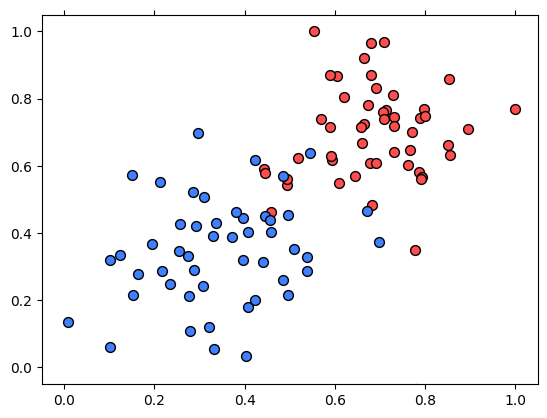

In [ ]:
boundary_lines = train_perceptron_algorithm(X, y)

plt.xlim(-0.05,1.05)
plt.ylim(-0.05,1.05)
plt.grid(False)
plt.tick_params(axis='x', which='both', bottom='off', top='off')

red = [1,0.3,0.3]
blue = [0.25,0.5,1]
red_points = X[np.argwhere(y==0).flatten()]
blue_points = X[np.argwhere(y==1).flatten()]
plt.scatter(red_points[:,0], red_points[:,1], s=50, color=red, edgecolor='k')
plt.scatter(blue_points[:,0], blue_points[:,1], s=50, color=blue, edgecolor='k')

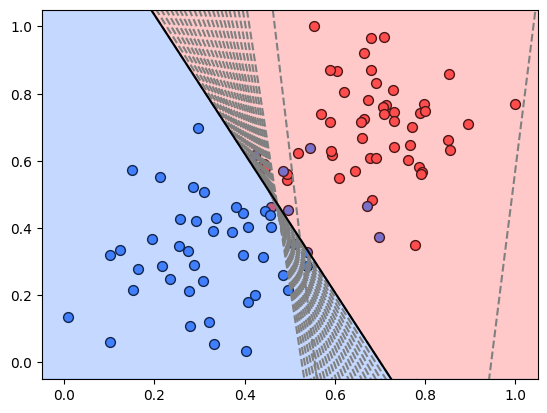

In [16]:
plt.xlim(-0.05,1.05)
plt.ylim(-0.05,1.05)
plt.scatter(red_points[:,0], red_points[:,1], s=50, color=red, edgecolor='k')
plt.scatter(blue_points[:,0], blue_points[:,1], s=50, color=blue, edgecolor='k')
for line in boundary_lines:
    slope = line[0]
    b = line[1]
    plot_line(slope, b)
solution_slope = boundary_lines[-1][0]
solution_intercept = boundary_lines[-1][1]
plot_line(solution_slope, solution_intercept, 'solid', 'k', True)
plt.show()